# Week 4 — Exploratory Data Analysis (EDA)

## Credit Card Protection
### Credit Card Fraud Detection

**Course:** Data Science and Visualization — 24ADI204

### Objective
To explore the cleaned Credit Card Fraud Detection dataset using statistical analysis and data visualization techniques.

### Activities
- Class distribution analysis
- Transaction amount distribution
- Transaction amount comparison by class
- Statistical comparison
- Correlation analysis
- Correlation heatmap
- Selected feature distributions
- Feature comparison by class
- Outlier analysis


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Dataset

In [ ]:
# Upload the dataset in Google Colab if it is not already present
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("creditcard.csv")
print("Dataset loaded successfully!")
print("Original shape:", df.shape)

Dataset loaded successfully!
Original shape: (284807, 31)


## 2. Use the Cleaned Dataset

In [ ]:
# Remove duplicate records identified during Week 3
df = df.drop_duplicates()

print("Cleaned dataset shape:", df.shape)
print("Duplicate rows remaining:", df.duplicated().sum())

Cleaned dataset shape: (283726, 31)
Duplicate rows remaining: 0


## 3. Class Distribution

In [ ]:
class_counts = df["Class"].value_counts()
class_percentage = df["Class"].value_counts(normalize=True) * 100

print("Transaction class counts:")
print(class_counts)

print("\nTransaction class percentages:")
print(class_percentage)

Transaction class counts:
0    283253
1    473

Transaction class percentages:
0    99.83329
1    0.16671


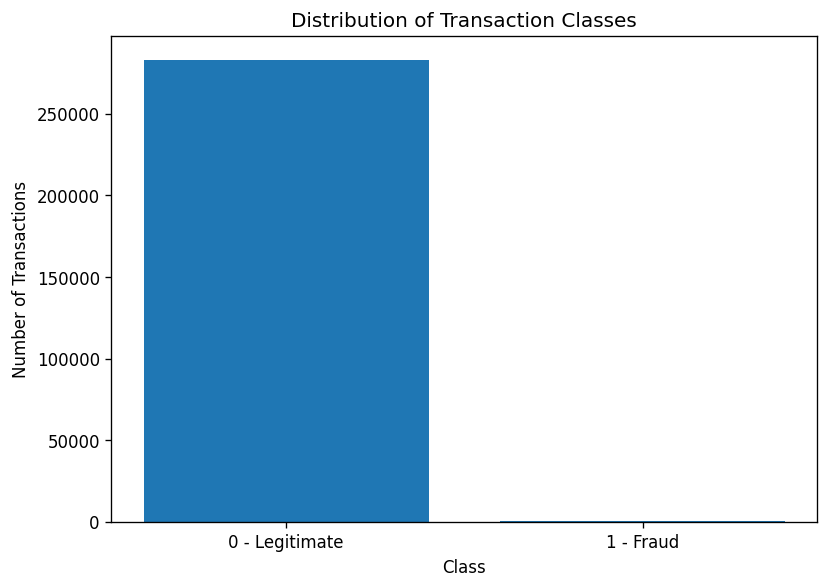

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(x="Class", data=df)
plt.title("Distribution of Transaction Classes")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

**Observation:** The target variable is highly imbalanced. Legitimate transactions greatly outnumber fraudulent transactions.

## 4. Transaction Amount Distribution

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Amount"], bins=50, kde=True)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

**Observation:** The transaction amount distribution is right-skewed, with many observations concentrated at smaller amounts and fewer observations at larger amounts.

## 5. Transaction Amount by Class

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")
plt.show()

In [ ]:
average_amount = df.groupby("Class")["Amount"].mean()
print("Average transaction amount:")
print(average_amount)

print("\nStatistical summary by class:")
print(df.groupby("Class")["Amount"].describe())

Average transaction amount:
0     88.291022
1    122.211321

Statistical summary by class:
Class 0 — count: 283253, mean: 88.291022, median: 22.00
Class 1 — count: 473, mean: 122.211321, median: 9.25


**Observation:** The boxplot and group statistics allow comparison of transaction amount distributions between legitimate and fraudulent transactions.

## 6. Correlation Analysis

In [ ]:
correlation = df.corr(numeric_only=True)
class_correlation = correlation["Class"].sort_values(ascending=False)

print("Correlation with Class:")
print(class_correlation)

Correlation with Class:
Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
...
V10     -0.216883
V12     -0.260593
V14     -0.302544
V17     -0.326481


In [ ]:
plt.figure(figsize=(15, 12))
sns.heatmap(correlation, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
strongest_correlations = (
    correlation["Class"]
    .abs()
    .sort_values(ascending=False)
)

print("Strongest absolute correlations with Class:")
print(strongest_correlations)

Strongest absolute correlations with Class:
Class    1.000000
V17      0.326481
V14      0.302544
V12      0.260593
V10      0.216883
V16      0.196539
...


**Observation:** Correlation analysis shows that several anonymized V-features have stronger statistical associations with the target than others. Correlation does not by itself establish causation.

## 7. Selected Feature Distributions

In [ ]:
plt.figure(figsize=(7, 5))
sns.histplot(df["V1"], bins=50, kde=True)
plt.title("Distribution of V1")
plt.xlabel("V1")
plt.ylabel("Frequency")
plt.show()

In [ ]:
plt.figure(figsize=(7, 5))
sns.histplot(df["V2"], bins=50, kde=True)
plt.title("Distribution of V2")
plt.xlabel("V2")
plt.ylabel("Frequency")
plt.show()

In [ ]:
plt.figure(figsize=(7, 5))
sns.histplot(df["V3"], bins=50, kde=True)
plt.title("Distribution of V3")
plt.xlabel("V3")
plt.ylabel("Frequency")
plt.show()

In [ ]:
plt.figure(figsize=(7, 5))
sns.histplot(df["V4"], bins=50, kde=True)
plt.title("Distribution of V4")
plt.xlabel("V4")
plt.ylabel("Frequency")
plt.show()

The `V1`–`V28` columns are anonymized numerical features. Their distributions are analyzed without assigning unsupported real-world meanings to them.

## 8. Selected Features by Class

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Class", y="V1", data=df)
plt.title("V1 Distribution by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("V1")
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Class", y="V2", data=df)
plt.title("V2 Distribution by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("V2")
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Class", y="V3", data=df)
plt.title("V3 Distribution by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("V3")
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Class", y="V4", data=df)
plt.title("V4 Distribution by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("V4")
plt.show()

## 9. Outlier Analysis — Amount

In [ ]:
Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Amount"] < lower_bound) |
    (df["Amount"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Amount outliers:", len(outliers))

**Observation:** Potential outliers are identified using the IQR method. They are not automatically removed because unusual transaction values may contain useful information for fraud analysis.

## 10. Final Dataset Check

In [ ]:
print("Final Dataset Shape:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())
print("Total Duplicate Rows:", df.duplicated().sum())

Final Dataset Shape: (283726, 31)
Total Missing Values: 0
Total Duplicate Rows: 0


## 11. Save Cleaned Dataset

In [ ]:
df.to_csv("creditcard_cleaned.csv", index=False)
print("Cleaned dataset saved successfully!")

# Week 4 — Conclusion

Exploratory Data Analysis was performed on the cleaned Credit Card Fraud Detection dataset.

The class distribution showed a strong imbalance between legitimate and fraudulent transactions.

The transaction amount distribution was analyzed using a histogram and showed a right-skewed distribution.

A boxplot was used to compare transaction amounts between legitimate and fraudulent transactions.

Correlation analysis was performed using a correlation matrix and heatmap to understand relationships between numerical features and the target variable.

Selected anonymized features were analyzed using histograms and boxplots.

The EDA provided an initial understanding of the distributions, relationships and patterns present in the transaction data.